In [1]:
import pandas as pd
import plotly.express as px

df = pd.read_excel("coupangplay_dataproject_survey_179.xlsx")

print(df.shape)
print(df.columns)

(179, 34)
Index(['타임스탬프',
       '[개인정보 수집 및 이용 동의]\n본 설문조사를 통해 수집된 개인정보 및 응답 내용은 쿠팡플레이 사용자 경험 분석 및 서비스 개선 방향 도출을 위한 통계 분석 목적으로만 활용됩니다.\n수집 항목 : 성별, 연령대, 직업, OTT 이용 행태 및 서비스 이용 경험 관련 응답\n보유 기간 : 수집일로부터 6개월\n귀하는 개인정보 제공을 거부할 권리가 있으며, 동의를 거부할 경우 설문 참여가 제한될 수 있습니다.',
       '연령대', '성별', '직업', '1. 현재 구독 중인 OTT 플랫폼을 모두 선택해주세요. (중복 선택 가능)',
       '2. 최근 1주일 기준, 하루 평균 OTT 시청 시간은 어떻게 되나요?', '3. 쿠팡플레이를 사용해보셨나요?',
       '4. 쿠팡플레이는 스포츠 콘텐츠가 강한 플랫폼이라고 생각한다.',
       '5. 쿠팡플레이는 예능 콘텐츠가 강한 플랫폼이라고 생각한다.',
       '6. 쿠팡플레이는 드라마 콘텐츠가 강한 플랫폼이라고 생각한다.',
       '7. 쿠팡플레이는 짧은 시간에 보기 좋은 콘텐츠가 부족하다고 생각한다.',
       '8. 쿠팡플레이에 새로운 콘텐츠 형식이 추가될 필요가 있다고 생각한다.',
       '9. 쿠팡플레이는 넷플릭스·티빙에 비해 경쟁력이 있다고 생각한다.',
       '10. 최근 1주일 기준, 하루 평균 숏폼 콘텐츠(틱톡·쇼츠·릴스) 시청 시간은 어떻게 되나요?',
       '11. 숏폼 콘텐츠 중 가장 자주 보는 유형은 무엇인가요?',
       '12. 나는 긴 영상보다 짧은 영상을 더 부담 없이 시청한다.',
       '13. 드라마나 예능도 짧은 형식이면 더 자주 볼 것 같다.', '14. 한 편의 길이가 길어 끝까지 보기 부담스럽다.',
       '15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.', '16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다.',
 

In [3]:
gender_col = "성별"
age_col = "연령대"
ott_col = "1. 현재 구독 중인 OTT 플랫폼을 모두 선택해주세요. (중복 선택 가능)"
ott_time_col = "2. 최근 1주일 기준, 하루 평균 OTT 시청 시간은 어떻게 되나요?"

total = len(df)
print("전체 응답자 수:", total)

전체 응답자 수: 179


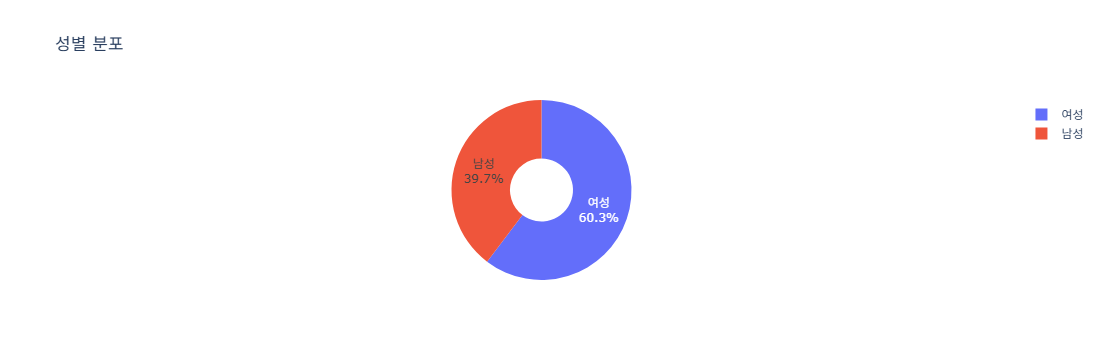

In [4]:
gender_df = df[gender_col].value_counts().reset_index()
gender_df.columns = ["성별", "응답자 수"]

gender_df["비율"] = gender_df["응답자 수"] / total * 100

fig = px.pie(
    gender_df,
    names="성별",
    values="응답자 수",
    title="성별 분포",
    hole=0.35
)

fig.update_traces(
    textinfo="label+percent",
    hovertemplate="%{label}<br>응답자 수: %{value}명<br>비율: %{percent}<extra></extra>"
)

fig.show()

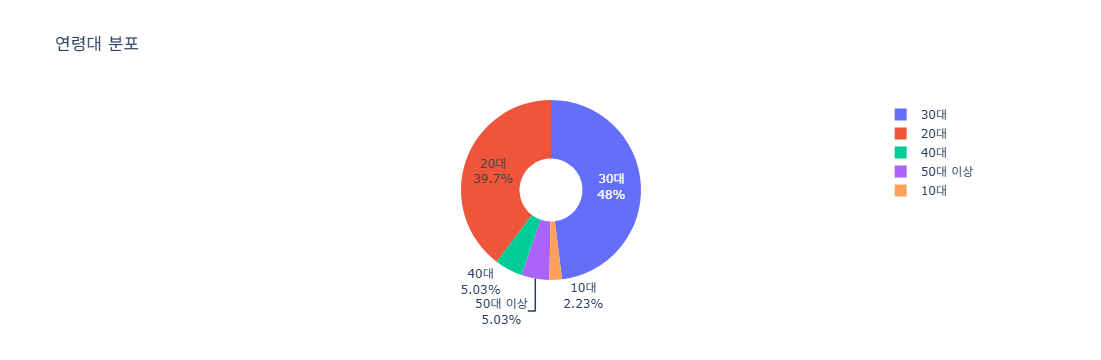

In [5]:
age_order = ["10대", "20대", "30대", "40대", "50대 이상"]

age_df = df[age_col].value_counts().reindex(age_order).dropna().reset_index()
age_df.columns = ["연령대", "응답자 수"]

fig = px.pie(
    age_df,
    names="연령대",
    values="응답자 수",
    title="연령대 분포",
    hole=0.35
)

fig.update_traces(
    textinfo="label+percent",
    hovertemplate="%{label}<br>응답자 수: %{value}명<br>비율: %{percent}<extra></extra>"
)

fig.show()

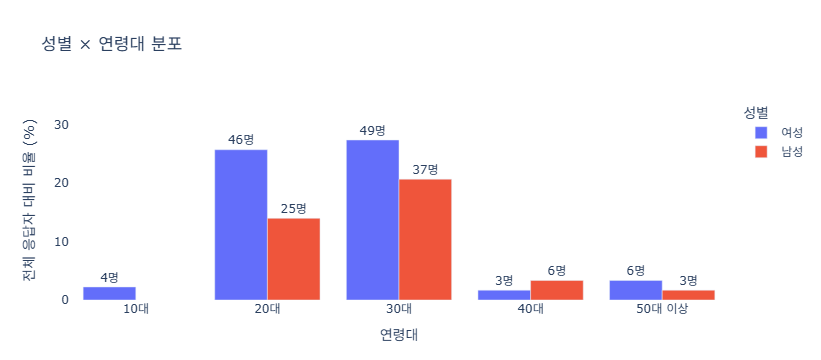

In [8]:
age_col = "연령대" 

merged = df.groupby([age_col, "성별"]).agg(
    응답자_수=("성별", "count")
).reset_index()

merged["전체 대비 비율"] = (merged["응답자_수"] / len(df) * 100).round(2)
merged = merged.rename(columns={"응답자_수": "응답자 수"})

fig = px.bar(
    merged,
    x=age_col,
    y="전체 대비 비율",
    color="성별",
    text="응답자 수",
    barmode="group",
    title="성별 × 연령대 분포"
)

fig.update_traces(
    texttemplate="%{text}명",
    textposition="outside",
    cliponaxis=False
)

fig.update_yaxes(
    title="전체 응답자 대비 비율 (%)",
    range=[0, merged["전체 대비 비율"].max() * 1.25]
)

fig.update_layout(
    margin=dict(t=100, b=60, l=70, r=40),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [6]:
job_col = "직업"

job_df = df[job_col].value_counts().reset_index()
job_df.columns = ["직업", "응답자 수"]

job_df["비율"] = job_df["응답자 수"] / total * 100
job_df["텍스트"] = (
    job_df["응답자 수"].astype(str) + "명<br>"
    + job_df["비율"].round(1).astype(str) + "%"
)

fig = px.bar(
    job_df,
    x="직업",
    y="응답자 수",
    text="텍스트",
    title="직업 분포"
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, job_df["응답자 수"].max()*1.3])

fig.show()

In [14]:
time_col = "2. 최근 1주일 기준, 하루 평균 OTT 시청 시간은 어떻게 되나요?"

time_df = df[time_col].value_counts().reset_index()
time_df.columns = ["OTT 시청시간", "응답자 수"]

# 순서 직접 지정
order = ["30분 미만", "30분~1시간", "1~2시간", "2시간 이상", "안 봄"]
time_df["OTT 시청시간"] = pd.Categorical(time_df["OTT 시청시간"], categories=order, ordered=True)
time_df = time_df.sort_values("OTT 시청시간")

time_df["텍스트"] = time_df["응답자 수"].astype(str) + "명"

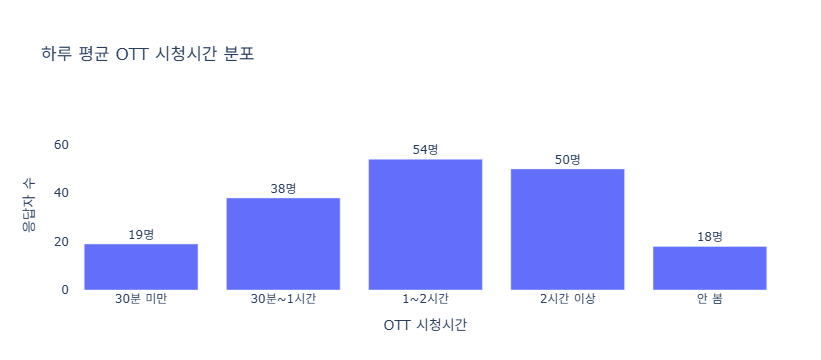

In [56]:
fig = px.bar(
    time_df,
    x="OTT 시청시간",
    y="응답자 수",
    text="텍스트",
    title="하루 평균 OTT 시청시간 분포"
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False
)

fig.update_yaxes(
    title="응답자 수",
    range=[0, time_df["응답자 수"].max() * 1.3]
)

fig.update_layout(
    margin=dict(t=120, b=70, l=70, r=40),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

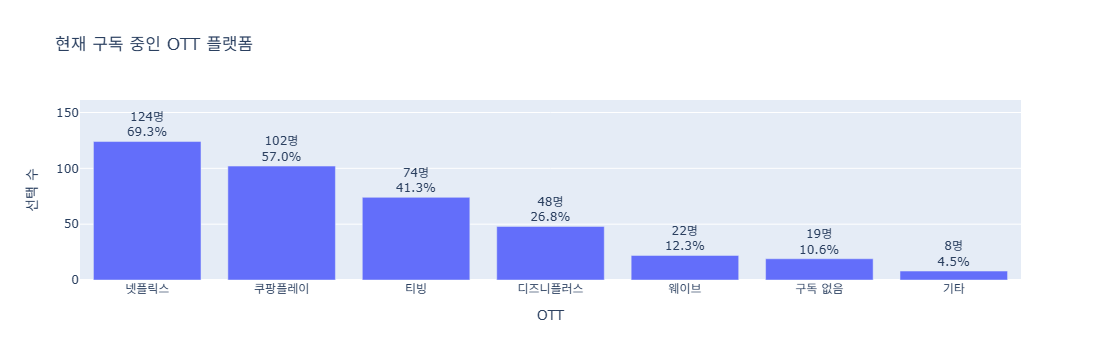

In [10]:
ott_col = "1. 현재 구독 중인 OTT 플랫폼을 모두 선택해주세요. (중복 선택 가능)"

ott_series = df[ott_col].dropna().astype(str)

ott_list = []
for row in ott_series:
    items = [x.strip() for x in row.replace("，", ",").split(",")]
    ott_list.extend(items)

ott_df = pd.DataFrame(ott_list, columns=["OTT"])

ott_count = ott_df["OTT"].value_counts().reset_index()
ott_count.columns = ["OTT", "선택 수"]

total = len(df)

ott_count["비율"] = ott_count["선택 수"] / total * 100
ott_count["텍스트"] = (
    ott_count["선택 수"].astype(str) + "명<br>"
    + ott_count["비율"].round(1).astype(str) + "%"
)

fig = px.bar(
    ott_count,
    x="OTT",
    y="선택 수",
    text="텍스트",
    title="현재 구독 중인 OTT 플랫폼"
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, ott_count["선택 수"].max()*1.3])

fig.show()

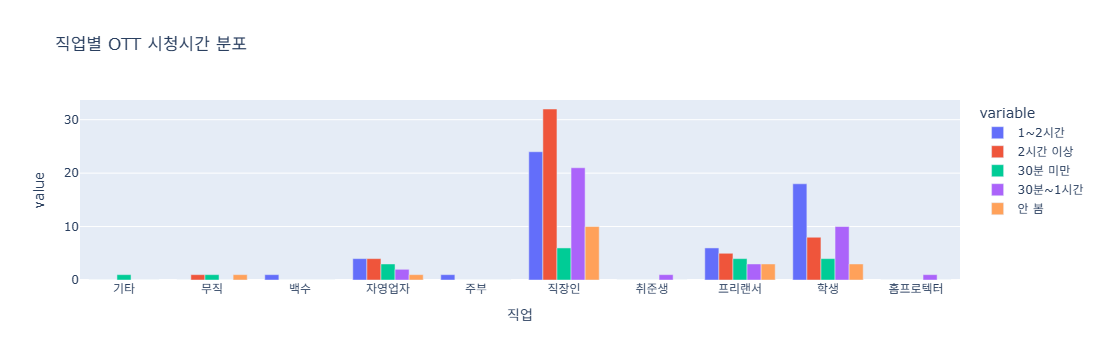

In [11]:
# "어떤 직업을 가진 사람이 ott를 많이 보는지" 분석

time_col = "2. 최근 1주일 기준, 하루 평균 OTT 시청 시간은 어떻게 되나요?"

cross = pd.crosstab(df[job_col], df[time_col])

fig = px.bar(
    cross.reset_index(),
    x="직업",
    y=cross.columns,
    barmode="group",
    title="직업별 OTT 시청시간 분포"
)

fig.show()

In [50]:
import pandas as pd

# 단일 문항 분석 함수
def analyze_single_item(df, col):
    result = df[col].value_counts(dropna=False).reset_index()
    result.columns = [col, '응답자 수']
    result['비율(%)'] = (result['응답자 수'] / len(df) * 100).round(1)
    
    print(f'\n[{col}] 빈도/비율')
    display(result)
    
    # 숫자형 문항일 경우 중앙값/최빈값 출력
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    
    if numeric_col.notna().sum() > 0:
        print('중앙값(Median):', numeric_col.median())
        print('최빈값(Mode):', numeric_col.mode().tolist())

In [17]:
cols = [
    "14. 한 편의 길이가 길어 끝까지 보기 부담스럽다.",
    "15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.",
    "7. 쿠팡플레이는 짧은 시간에 보기 좋은 콘텐츠가 부족하다고 생각한다."
]

df[cols].mean()

14. 한 편의 길이가 길어 끝까지 보기 부담스럽다.              3.083799
15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.          3.324022
7. 쿠팡플레이는 짧은 시간에 보기 좋은 콘텐츠가 부족하다고 생각한다.    3.134078
dtype: float64

In [21]:
short_cols = [
    "12. 나는 긴 영상보다 짧은 영상을 더 부담 없이 시청한다.",
    "13. 드라마나 예능도 짧은 형식이면 더 자주 볼 것 같다.",
    "16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다.",
]

df[short_cols].mean()

12. 나는 긴 영상보다 짧은 영상을 더 부담 없이 시청한다.    3.754190
13. 드라마나 예능도 짧은 형식이면 더 자주 볼 것 같다.     3.128492
16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다.      3.145251
dtype: float64

In [19]:
df[[
    "15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.",
    "16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다."
]].corr()

,15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.,16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다.
15. 시간이 부족해 OTT 콘텐츠를 자주 시청하지 못한다.,1.000000,0.024812
16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다.,0.024812,1.000000


In [59]:
target = "16. 쿠팡플레이 숏폼 드라마·예능을 시청할 의향이 있다."

corr_cols = [
    "12. 나는 긴 영상보다 짧은 영상을 더 부담 없이 시청한다.",
    "13. 드라마나 예능도 짧은 형식이면 더 자주 볼 것 같다.",
    "17. 쿠팡플레이 숏폼 콘텐츠가 있다면 기존보다 더 자주 접속할 것 같다.",
    "18. 웹툰·웹소설 원작 숏폼 드라마를 선호한다.",
    "19. 쿠팡플레이 오리지널 숏폼 콘텐츠를 선호한다.",
    "20. 해외 숏폼 드라마를 선호한다.",
    "21. 예능·코미디 숏폼 콘텐츠를 선호한다.",
    "22. 스포츠 관련 숏폼 콘텐츠를 선호한다.",
    "23. 숏폼 콘텐츠 시청 시 쿠팡캐시를 지급하면 이용할 마음이 높아질 것 같다.",
    "24. 숏폼 콘텐츠와 쿠팡 쇼핑 혜택이 연결되면 더 자주 이용할 것 같다."
]

result = []

for col in corr_cols:
    corr = df[[col, target]].corr().iloc[0, 1]
    result.append({
        "변수": col,
        "상관계수": round(corr, 3)
    })

corr_result = pd.DataFrame(result).sort_values("상관계수", ascending=False)
corr_result

# 0.5 ~ 0.8: 강한 상관관계
# 0.3 ~ 0.5: 중간 수준의 상관관계
# 0.3 미만: 약한 상관관계 (연관성을 찾기 어려움)

,변수,상관계수
2,17. 쿠팡플레이 숏폼 콘텐츠가 있다면 기존보다 더 자주 접속할 것 같다.,0.775
4,19. 쿠팡플레이 오리지널 숏폼 콘텐츠를 선호한다.,0.453
3,18. 웹툰·웹소설 원작 숏폼 드라마를 선호한다.,0.443
1,13. 드라마나 예능도 짧은 형식이면 더 자주 볼 것 같다.,0.427
6,21. 예능·코미디 숏폼 콘텐츠를 선호한다.,0.376
5,20. 해외 숏폼 드라마를 선호한다.,0.372
8,23. 숏폼 콘텐츠 시청 시 쿠팡캐시를 지급하면 이용할 마음이 높아질 것 같다.,0.310
9,24. 숏폼 콘텐츠와 쿠팡 쇼핑 혜택이 연결되면 더 자주 이용할 것 같다.,0.303
0,12. 나는 긴 영상보다 짧은 영상을 더 부담 없이 시청한다.,0.210
7,22. 스포츠 관련 숏폼 콘텐츠를 선호한다.,0.189


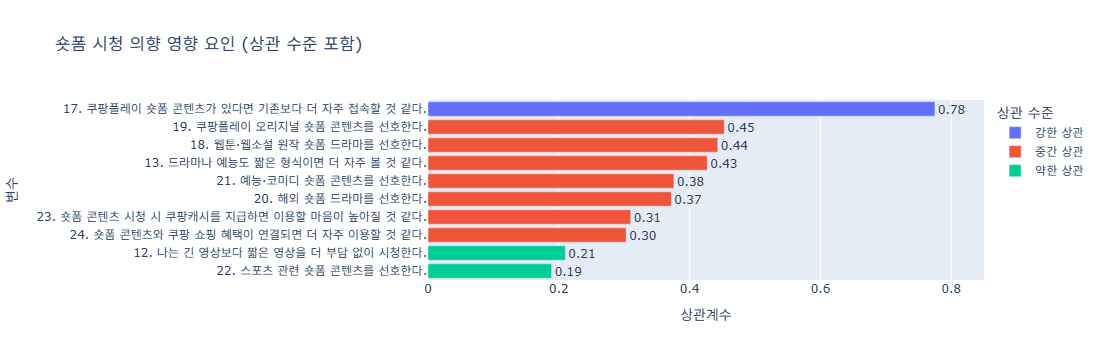

In [74]:
import plotly.express as px

def corr_level(x):
    if x >= 0.5:
        return "강한 상관"
    elif x >= 0.3:
        return "중간 상관"
    else:
        return "약한 상관"

corr_result["상관 수준"] = corr_result["상관계수"].apply(corr_level)

fig = px.bar(
    corr_result,
    x="상관계수",
    y="변수",
    color="상관 수준",
    orientation="h",
    text="상관계수",
    title="숏폼 시청 의향 영향 요인 (상관 수준 포함)"
)
fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_xaxes(range=[0, 0.85]) 

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    margin=dict(r=80)
)

fig.show()

In [30]:
col = "11. 숏폼 콘텐츠 중 가장 자주 보는 유형은 무엇인가요?"

content_df = df[col].value_counts().reset_index()

content_df.columns = ["콘텐츠 유형", "응답자 수"]

total = len(df)
content_df["비율(%)"] = (content_df["응답자 수"] / total * 100).round(1)

content_df["텍스트"] = (
    content_df["응답자 수"].astype(str) + "명<br>" +
    content_df["비율(%)"].astype(str) + "%"
)

content_df.head()

,콘텐츠 유형,응답자 수,비율(%),텍스트
0,예능·코미디,72,40.2,72명<br>40.2%
1,정보·뉴스,34,19.0,34명<br>19.0%
2,먹방·일상,32,17.9,32명<br>17.9%
3,드라마·스토리,19,10.6,19명<br>10.6%
4,스포츠,10,5.6,10명<br>5.6%


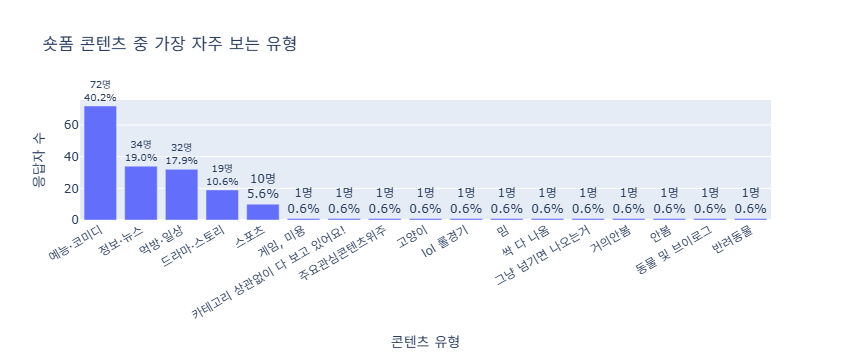

In [77]:
# 사람들이 자주 보는 숏폼 콘텐츠 유형

import plotly.express as px

fig = px.bar(
    content_df,
    x="콘텐츠 유형",
    y="응답자 수",
    text="텍스트",
    title="숏폼 콘텐츠 중 가장 자주 보는 유형"
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False
)

fig.update_layout(
    xaxis_tickangle=-30,
    margin=dict(t=100, b=120)
)

fig.show()

In [51]:
# 쿠팡플레이가 어떤 장르에 강하다고 인식되는지

genre_strength_cols = [
    "4. 쿠팡플레이는 스포츠 콘텐츠가 강한 플랫폼이라고 생각한다.",
    "5. 쿠팡플레이는 예능 콘텐츠가 강한 플랫폼이라고 생각한다.",
    "6. 쿠팡플레이는 드라마 콘텐츠가 강한 플랫폼이라고 생각한다."
]

# 숫자로 변환
df[genre_strength_cols] = df[genre_strength_cols].apply(pd.to_numeric, errors='coerce')

# 평균 / 중앙값 / 최빈값 계산
genre_strength = pd.DataFrame({
    "문항": genre_strength_cols,
    "평균": df[genre_strength_cols].mean().round(2),
    "중앙값": df[genre_strength_cols].median(),
    "최빈값": [df[col].mode().iloc[0] for col in genre_strength_cols]
}).reset_index(drop=True)

genre_strength["장르"] = ["스포츠", "예능", "드라마"]

genre_strength

# “쿠팡플레이는 특정 장르가 ‘압도적으로 강하다’고 인식되지는 않는다”
# 그래도 상대적으로, 스포츠 > 예능 > 드라마
# 스포츠 → 약한 강점 / 예능 → 애매 / 드라마 → 약함
# 성별로 나눠서 확인도 해봤는데, 차이가 없음

,문항,평균,중앙값,최빈값,장르
0,4. 쿠팡플레이는 스포츠 콘텐츠가 강한 플랫폼이라고 생각한다.,3.28,3.0,4,스포츠
1,5. 쿠팡플레이는 예능 콘텐츠가 강한 플랫폼이라고 생각한다.,3.18,3.0,3,예능
2,6. 쿠팡플레이는 드라마 콘텐츠가 강한 플랫폼이라고 생각한다.,2.92,3.0,3,드라마


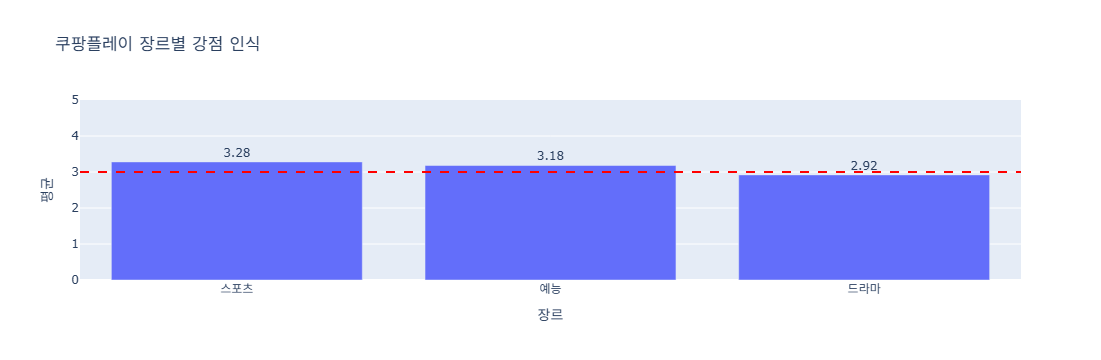

In [75]:
fig = px.bar(
    genre_strength,
    x="장르",
    y="평균",
    text="평균",
    title="쿠팡플레이 장르별 강점 인식"
)

fig.add_hline(y=3, line_dash="dash", line_color="red")

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.update_yaxes(range=[0, 5])

fig.show()

In [53]:
# 사용자들이 선호하는 숏폼 장르

import pandas as pd
import plotly.express as px

preference_cols = [
    "18. 웹툰·웹소설 원작 숏폼 드라마를 선호한다.",
    "19. 쿠팡플레이 오리지널 숏폼 콘텐츠를 선호한다.",
    "20. 해외 숏폼 드라마를 선호한다.",
    "21. 예능·코미디 숏폼 콘텐츠를 선호한다.",
    "22. 스포츠 관련 숏폼 콘텐츠를 선호한다."
]

# 숫자 변환
df[preference_cols] = df[preference_cols].apply(pd.to_numeric, errors='coerce')

# 통계 계산
pref_df = pd.DataFrame({
    "문항": preference_cols,
    "평균": df[preference_cols].mean().round(2),
    "중앙값": df[preference_cols].median(),
    "최빈값": [df[col].mode().iloc[0] for col in preference_cols]
}).reset_index(drop=True)

pref_df["콘텐츠 유형"] = [
    "웹툰·웹소설 원작",
    "쿠팡플레이 오리지널",
    "해외 숏폼 드라마",
    "예능·코미디",
    "스포츠"
]

# 평균 기준 정렬
pref_df = pref_df.sort_values("평균", ascending=False)

pref_df

,문항,평균,중앙값,최빈값,콘텐츠 유형
3,21. 예능·코미디 숏폼 콘텐츠를 선호한다.,3.39,4.0,4,예능·코미디
1,19. 쿠팡플레이 오리지널 숏폼 콘텐츠를 선호한다.,2.98,3.0,3,쿠팡플레이 오리지널
0,18. 웹툰·웹소설 원작 숏폼 드라마를 선호한다.,2.80,3.0,3,웹툰·웹소설 원작
4,22. 스포츠 관련 숏폼 콘텐츠를 선호한다.,2.63,3.0,3,스포츠
2,20. 해외 숏폼 드라마를 선호한다.,2.54,2.0,2,해외 숏폼 드라마


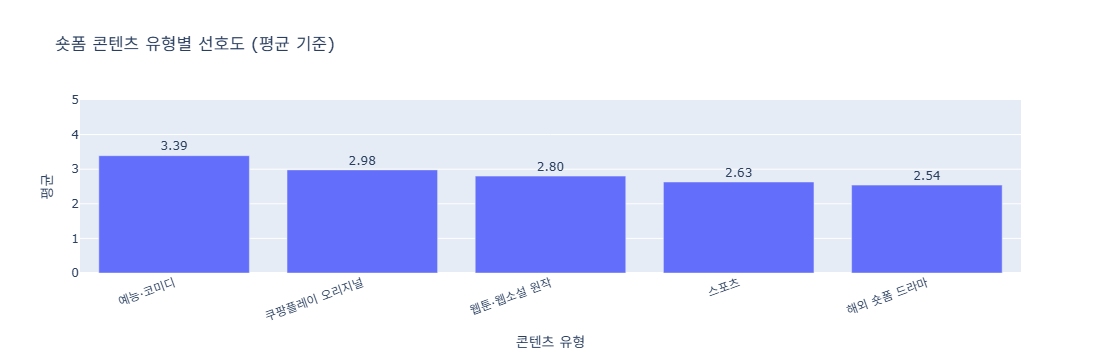

In [54]:
fig = px.bar(
    pref_df,
    x="콘텐츠 유형",
    y="평균",
    text="평균",
    title="숏폼 콘텐츠 유형별 선호도 (평균 기준)"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.update_yaxes(range=[0, 5])
fig.update_layout(xaxis_tickangle=-20)

fig.show()

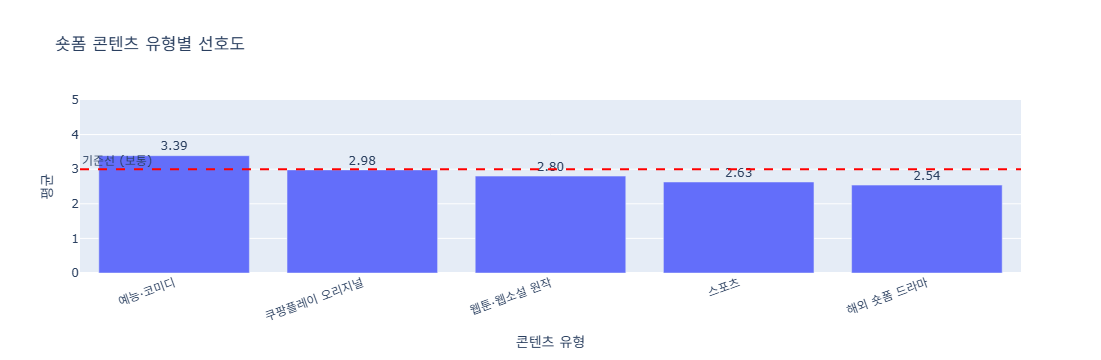

In [76]:
fig = px.bar(
    pref_df,
    x="콘텐츠 유형",
    y="평균",
    text="평균",
    title="숏폼 콘텐츠 유형별 선호도"
)

# 👉 기준선 추가 (핵심)
fig.add_hline(
    y=3,
    line_dash="dash",
    line_color="red",
    annotation_text="기준선 (보통)",
    annotation_position="top left"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_yaxes(range=[0, 5])
fig.update_layout(xaxis_tickangle=-20)

fig.show()

In [78]:
col = "9. 쿠팡플레이는 넷플릭스·티빙에 비해 경쟁력이 있다고 생각한다."

# 기본 분포
comp_df = df[col].value_counts().sort_index().reset_index()
comp_df.columns = ["점수", "응답자 수"]

total = len(df)
comp_df["비율(%)"] = (comp_df["응답자 수"] / total * 100).round(1)

# 텍스트
comp_df["텍스트"] = (
    comp_df["응답자 수"].astype(str) + "명<br>" +
    comp_df["비율(%)"].astype(str) + "%"
)

# 추가 통계
mean_val = round(df[col].mean(), 2)
median_val = df[col].median()
mode_val = df[col].mode().iloc[0]

print("평균:", mean_val)
print("중앙값:", median_val)
print("최빈값:", mode_val)

평균: 2.7
중앙값: 3.0
최빈값: 3


In [82]:
col = "9. 쿠팡플레이는 넷플릭스·티빙에 비해 경쟁력이 있다고 생각한다."

df["경쟁력_구간"] = df[col].apply(
    lambda x: "부정 (1~2점)" if x <= 2 else ("보통 (3점)" if x == 3 else "긍정 (4~5점)")
)

comp_group = df["경쟁력_구간"].value_counts().reset_index()
comp_group.columns = ["구간", "응답자 수"]

total = len(df)
comp_group["비율(%)"] = (comp_group["응답자 수"] / total * 100).round(1)

comp_group["텍스트"] = (
    comp_group["응답자 수"].astype(str) + "명<br>" +
    comp_group["비율(%)"].astype(str) + "%"
)

comp_group

,구간,응답자 수,비율(%),텍스트
0,부정 (1~2점),81,45.3,81명<br>45.3%
1,보통 (3점),59,33.0,59명<br>33.0%
2,긍정 (4~5점),39,21.8,39명<br>21.8%


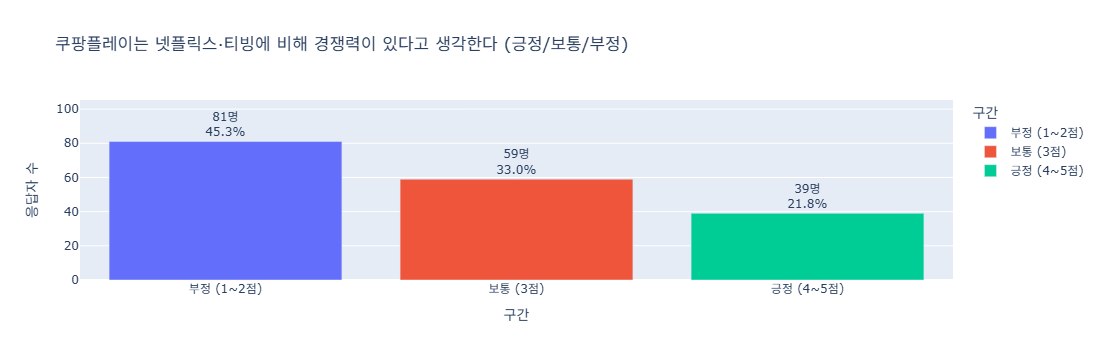

In [84]:
import plotly.express as px

fig = px.bar(
    comp_group,
    x="구간",
    y="응답자 수",
    text="텍스트",
    color="구간",
    title="쿠팡플레이는 넷플릭스·티빙에 비해 경쟁력이 있다고 생각한다 (긍정/보통/부정)"
)

fig.update_traces(textposition="outside", cliponaxis=False)

fig.update_layout(
    yaxis=dict(range=[0, comp_group["응답자 수"].max() * 1.3])
)

fig.show()

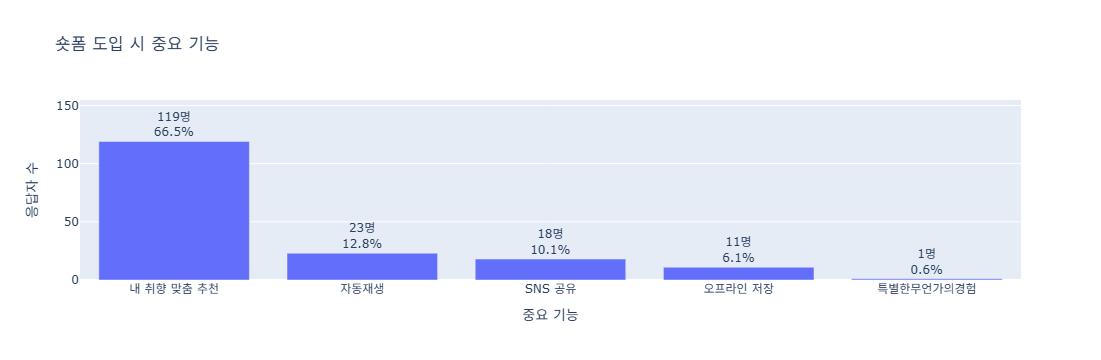

,중요 기능,응답자 수,비율(%),텍스트
0,내 취향 맞춤 추천,119,66.5,119명<br>66.5%
1,자동재생,23,12.8,23명<br>12.8%
2,SNS 공유,18,10.1,18명<br>10.1%
3,오프라인 저장,11,6.1,11명<br>6.1%
4,특별한무언가의경험,1,0.6,1명<br>0.6%


In [41]:
# 숏폼 도입 시 중요 기능

col = "25. 쿠팡플레이 숏폼 드라마·예능이 생긴다면 어떤 기능이 가장 중요할 것 같나요? (1순위)"

feature_df = df[col].value_counts().reset_index().head()
feature_df.columns = ["중요 기능", "응답자 수"]

feature_df["비율(%)"] = (feature_df["응답자 수"] / total * 100).round(1)
feature_df["텍스트"] = (
    feature_df["응답자 수"].astype(str) + "명<br>" +
    feature_df["비율(%)"].astype(str) + "%"
)

fig = px.bar(
    feature_df,
    x="중요 기능",
    y="응답자 수",
    text="텍스트",
    title="숏폼 도입 시 중요 기능"
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, feature_df["응답자 수"].max() * 1.3])
fig.show()

feature_df

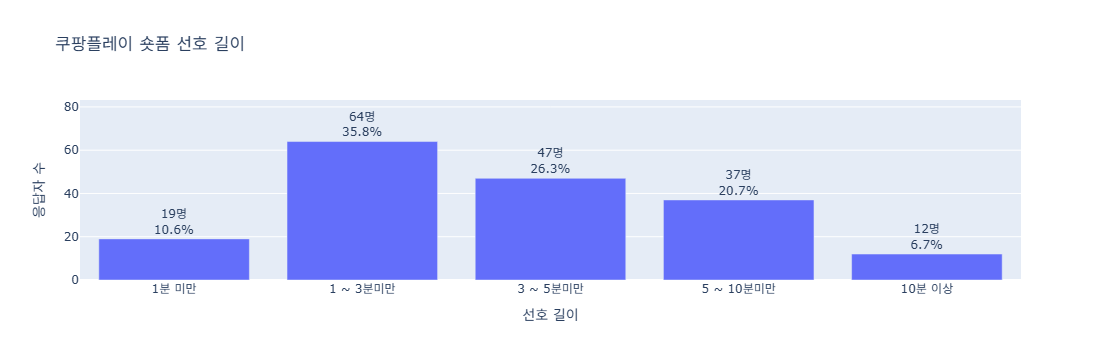

,선호 길이,응답자 수,비율(%),텍스트
0,1분 미만,19,10.6,19명<br>10.6%
1,1 ~ 3분미만,64,35.8,64명<br>35.8%
2,3 ~ 5분미만,47,26.3,47명<br>26.3%
3,5 ~ 10분미만,37,20.7,37명<br>20.7%
4,10분 이상,12,6.7,12명<br>6.7%


In [42]:
# 선호 숏폼 길이

col = "26. 쿠팡플레이 숏폼 드라마·예능의 길이는 몇 분 정도가 적당할 것 같나요?"

length_order = ["1분 미만", "1 ~ 3분미만", "3 ~ 5분미만", "5 ~ 10분미만", "10분 이상"]

length_df = df[col].value_counts().reindex(length_order).dropna().reset_index()
length_df.columns = ["선호 길이", "응답자 수"]

length_df["비율(%)"] = (length_df["응답자 수"] / total * 100).round(1)
length_df["텍스트"] = (
    length_df["응답자 수"].astype(str) + "명<br>" +
    length_df["비율(%)"].astype(str) + "%"
)

fig = px.bar(
    length_df,
    x="선호 길이",
    y="응답자 수",
    text="텍스트",
    title="쿠팡플레이 숏폼 선호 길이"
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, length_df["응답자 수"].max() * 1.3])
fig.show()

length_df

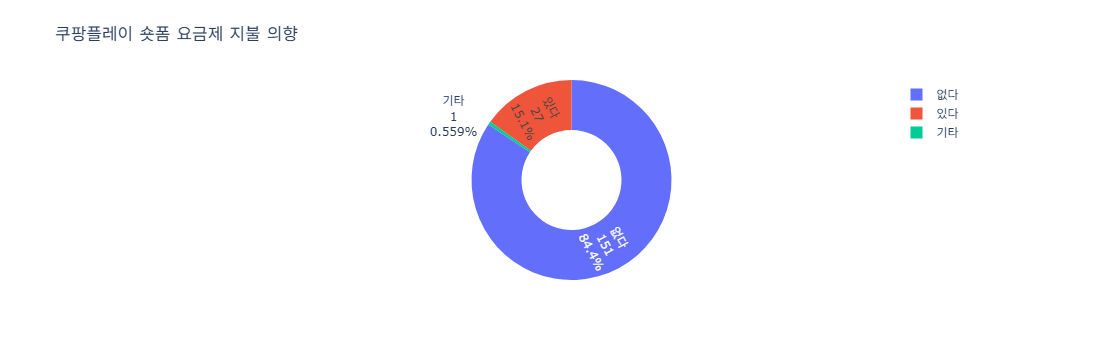

In [55]:
# 숏폼 요금제 지불 의향

col = "27. 숏폼 콘텐츠만을 위해 별도 요금제를 결제할 생각이 있나요?"

# 1. 값 정리
df[col] = df[col].apply(
    lambda x: x if x in ["있다", "없다"] else "기타"
)

# 2. 집계
pay_plan_df = df[col].value_counts().reset_index()
pay_plan_df.columns = ["별도 요금제 결제 의향", "응답자 수"]

# 3. 비율
total = len(df)
pay_plan_df["비율(%)"] = (pay_plan_df["응답자 수"] / total * 100).round(1)

pay_plan_df

fig = px.pie(
    pay_plan_df,
    names="별도 요금제 결제 의향",
    values="응답자 수",
    hole=0.5,
    title="쿠팡플레이 숏폼 요금제 지불 의향"
)

fig.update_traces(
    textinfo="label+percent+value",   
)

fig.update_layout(
    showlegend=True,
    margin=dict(t=80, b=80, l=80, r=80)
)

fig.show()

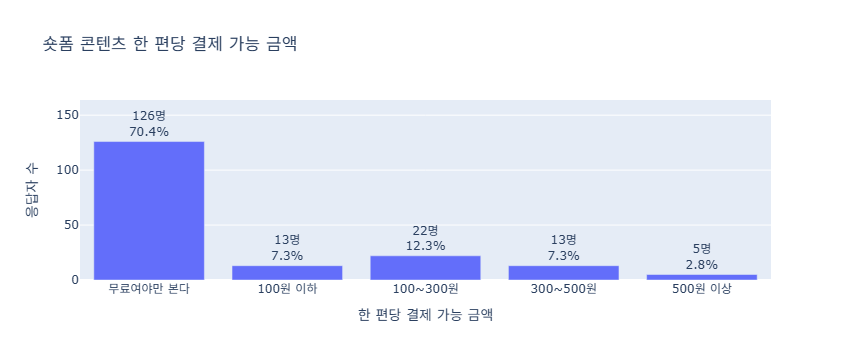

,한 편당 결제 가능 금액,응답자 수,비율(%),텍스트
0,무료여야만 본다,126,70.4,126명<br>70.4%
1,100원 이하,13,7.3,13명<br>7.3%
2,100~300원,22,12.3,22명<br>12.3%
3,300~500원,13,7.3,13명<br>7.3%
4,500원 이상,5,2.8,5명<br>2.8%


In [47]:
# 한 편당 결제 가능 금액

col = "28. 쿠팡플레이 숏폼 (드라마·예능) 콘텐츠는 한 편당 얼마까지 결제할 수 있나요?"

price_order = ["무료여야만 본다", "100원 이하", "100~300원", "300~500원", "500원 이상"]

price_df = df[col].value_counts().reindex(price_order).dropna().reset_index()
price_df.columns = ["한 편당 결제 가능 금액", "응답자 수"]

price_df["비율(%)"] = (price_df["응답자 수"] / total * 100).round(1)
price_df["텍스트"] = (
    price_df["응답자 수"].astype(str) + "명<br>" +
    price_df["비율(%)"].astype(str) + "%"
)

fig = px.bar(
    price_df,
    x="한 편당 결제 가능 금액",
    y="응답자 수",
    text="텍스트",
    title="숏폼 콘텐츠 한 편당 결제 가능 금액"
)

fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, price_df["응답자 수"].max() * 1.3])
fig.show()

price_df

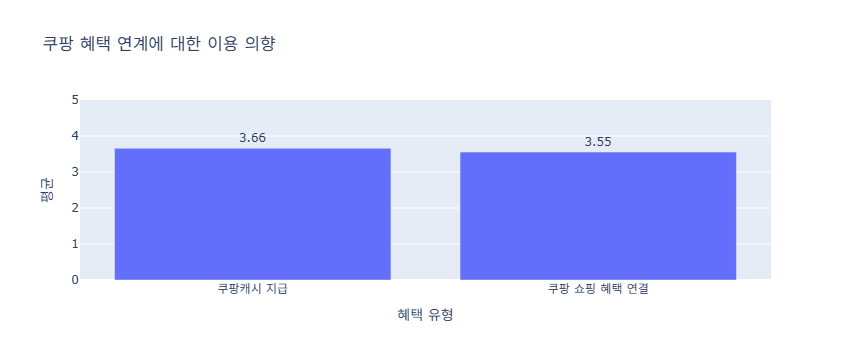

,문항,평균,혜택 유형
0,23. 숏폼 콘텐츠 시청 시 쿠팡캐시를 지급하면 이용할 마음이 높아질 것 같다.,3.659218,쿠팡캐시 지급
1,24. 숏폼 콘텐츠와 쿠팡 쇼핑 혜택이 연결되면 더 자주 이용할 것 같다.,3.553073,쿠팡 쇼핑 혜택 연결


In [86]:
# 쿠팡캐시 / 쇼핑 혜택 관련 분석

benefit_cols = [
    "23. 숏폼 콘텐츠 시청 시 쿠팡캐시를 지급하면 이용할 마음이 높아질 것 같다.",
    "24. 숏폼 콘텐츠와 쿠팡 쇼핑 혜택이 연결되면 더 자주 이용할 것 같다."
]

benefit_df = df[benefit_cols].mean().reset_index()
benefit_df.columns = ["문항", "평균"]

benefit_df["혜택 유형"] = ["쿠팡캐시 지급", "쿠팡 쇼핑 혜택 연결"]

fig = px.bar(
    benefit_df,
    x="혜택 유형",
    y="평균",
    text="평균",
    title="쿠팡 혜택 연계에 대한 이용 의향"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside", cliponaxis=False)
fig.update_yaxes(range=[0, 5])
fig.show()

benefit_df

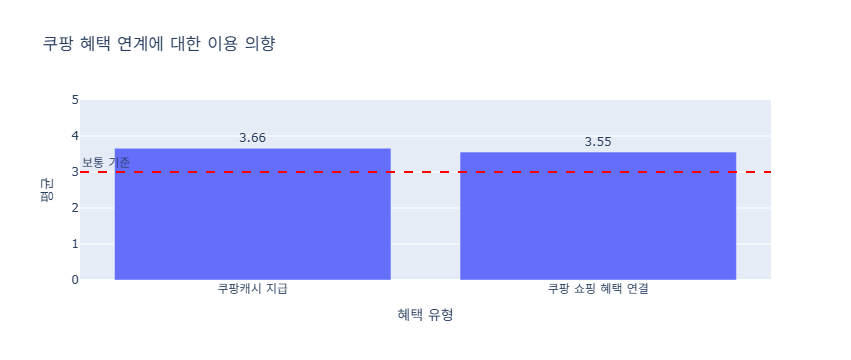

In [87]:
fig = px.bar(
    benefit_df,
    x="혜택 유형",
    y="평균",
    text="평균",
    title="쿠팡 혜택 연계에 대한 이용 의향"
)

# 기준선 (보통 = 3)
fig.add_hline(
    y=3,
    line_dash="dash",
    line_color="red",
    annotation_text="보통 기준",
    annotation_position="top left"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside",
    cliponaxis=False
)

fig.update_yaxes(range=[0, 5])

fig.show()